In [ ]:
import pandas as pd


In [ ]:
df4 = pd.read_csv('Dataset.csv')

In [ ]:
df4.head()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


In [ ]:
df4.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
country,0
date_added,0
release_year,0
rating,0
duration,0
listed_in,0


In [ ]:
from sklearn.preprocessing import LabelEncoder

features4 = df4[['type', 'country', 'rating', 'listed_in', 'release_year']].copy()

encoders4 = {}
for col in ['type', 'country', 'rating', 'listed_in']:
    le = LabelEncoder()
    features4[col] = le.fit_transform(features4[col])
    encoders4[col] = le

print(features4.head())

   type  country  rating  listed_in  release_year
0     0       80       4        273          2020
1     1       20       8        241          2021
2     1       80       8        498          2021
3     0        6       9        124          2021
4     0       80       8        318          1993


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Scale features so they're comparable
scaler = StandardScaler()
features4_scaled = scaler.fit_transform(features4)

# Apply K-Means clustering
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df4['cluster'] = kmeans.fit_predict(features4_scaled)

print(df4['cluster'].value_counts())

cluster
3    2630
2    2274
1    2069
0    1423
4     394
Name: count, dtype: int64


In [ ]:
for cluster_num in sorted(df4['cluster'].unique()):
    cluster_data = df4[df4['cluster'] == cluster_num]

In [ ]:
  print(f"\n--- Cluster {cluster_num} ({len(cluster_data)} titles) ---")


--- Cluster 4 (394 titles) ---


In [ ]:
print("Most common type:", cluster_data['type'].mode()[0])
print("Most common rating:", cluster_data['rating'].mode()[0])

Most common type: Movie
Most common rating: TV-14


In [ ]:
print("Top 3 countries:", cluster_data['country'].value_counts().head(3).to_dict())
print("Top 3 genres:", cluster_data['listed_in'].value_counts().head(3).to_dict())

Top 3 countries: {'United States': 187, 'India': 72, 'Hong Kong': 32}
Top 3 genres: {'Classic Movies, Dramas, International Movies': 16, 'Action & Adventure, Dramas, International Movies': 16, 'Action & Adventure, International Movies': 14}


In [ ]:
print("Avg release year:", round(cluster_data['release_year'].mean(), 1))

Avg release year: 1982.3


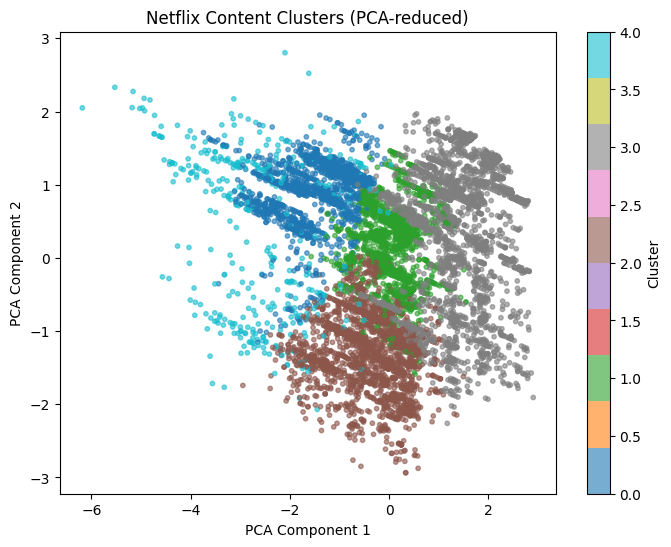

Variance explained by 2 components: 0.557


In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
features4_pca = pca.fit_transform(features4_scaled)

plt.figure(figsize=(8,6))
scatter = plt.scatter(features4_pca[:, 0], features4_pca[:, 1], c=df4['cluster'], cmap='tab10', alpha=0.6, s=10)
plt.title('Netflix Content Clusters (PCA-reduced)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(scatter, label='Cluster')
plt.show()

print("Variance explained by 2 components:", round(sum(pca.explained_variance_ratio_), 3))

In [ ]:
summary = df4.groupby('cluster').agg(
    num_titles=('show_id', 'count'),
    most_common_type=('type', lambda x: x.mode()[0]),
    most_common_rating=('rating', lambda x: x.mode()[0]),
    avg_release_year=('release_year', 'mean'),
    top_genre=('listed_in', lambda x: x.mode()[0])
).reset_index()

summary['avg_release_year'] = summary['avg_release_year'].round(1)
print(summary)


   cluster  num_titles most_common_type most_common_rating  avg_release_year  \
0        0        1423            Movie                  R            2012.0   
1        1        2069            Movie              TV-MA            2017.0   
2        2        2274            Movie              TV-14            2015.2   
3        3        2630          TV Show              TV-MA            2017.0   
4        4         394            Movie              TV-14            1982.3   

                                          top_genre  
0                Children & Family Movies, Comedies  
1                                     Documentaries  
2                      Dramas, International Movies  
3                                          Kids' TV  
4  Action & Adventure, Dramas, International Movies  


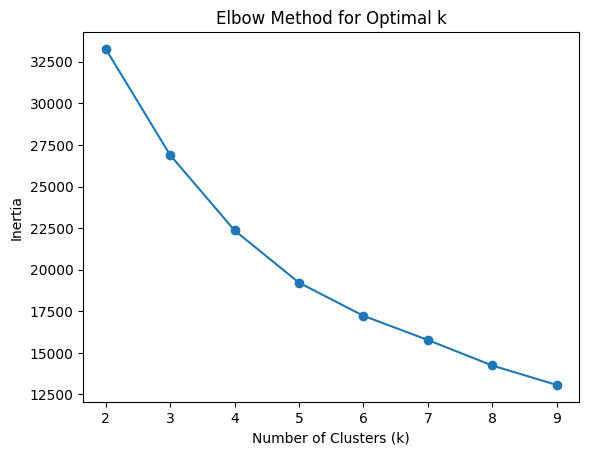

In [ ]:
inertias = []
K_range = range(2, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(features4_scaled)
    inertias.append(km.inertia_)

plt.plot(K_range, inertias, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()